Rubtcova Vera  
Algorithms Task 4

## Goal  
The use of stochastic and metaheuristic algorithms (Simulated Annealing,
Differential Evolution, Particle Swarm Optimization) in the tasks of unconstrained
nonlinear optimization and the experimental comparison of them with Nelder-Mead
and Levenberg-Marquardt algorithms  

In [349]:
import math
import pandas as pd
import random
import matplotlib.pyplot as plt

In [350]:
def generate_data():

  xs = []
  ys = []
  for k in range(1001):
    g = random.gauss(0,1)
    x_k = 3*k / 1000
    f_k = 1 / (x_k**2 - 3*x_k + 2)
    if f_k < -100:
      y_k = - 100 + g
    elif -100 <= f_k and f_k <= 100:
      y_k = f_k + g
    else:
      y_k = 100+g
    xs.append(x_k)
    ys.append(y_k)

  return xs, ys

In [351]:
def approximant(x, a, b, c, d):
  return (a*x + b) / (x**2 + c * x + d)

In [352]:
def D(F, a, b,  c, d, xs, ys):
  sum = 0
  for k in range(1001):
    sum += (F(xs[k], a, b, c, d) - ys[k])**2
  return sum

In [353]:
def f_D(F, point, xs, ys):
  a, b, c, d = point
  return D(F, a, b, c, d, xs, ys)

In [354]:
def matrix_solve(A, b):
  n = len(b)
  for k in range(n):
    for i in range(k+1, n):
      koef = A[i][k] / A[k][k]
      for j in range(n):
        A[i][j] = A[i][j] - (koef * A[k][j])
      b[i] = b[i] - (koef * b[k])

  x = [0] * n
  for i in range(n - 1, -1, -1):
    s = 0
    for j in range(i + 1, n):
      s+= A[i][j] * x[j]
    x[i] = (b[i] - s) / A[i][i]
  return x

In [355]:
def rational_residuals(a, b, c, d, xs, ys):
  lambdas = []
  for i in range(1001):
    lambdas.append(approximant(xs[i], a, b, c, d) - ys[i])
  return lambdas

## Task 1
Generate the noisy data (𝑥𝑘,𝑦𝑘), where 𝑘 = 0,…,1000, according to the rule:

𝑦ₖ = −100 + 𝛿ₖ, if 𝑓(𝑥ₖ) < −100  
𝑦ₖ = 𝑓(𝑥ₖ) + 𝛿ₖ, if −100 ≤ 𝑓(𝑥ₖ) ≤ 100  
𝑦ₖ = 100 + 𝛿ₖ, if 𝑓(𝑥ₖ) > 100  

𝑥ₖ = 3𝑘/1000,    

𝑓(𝑥) = 1 / (𝑥² − 3𝑥 + 2)  

where 𝛿𝑘~𝑁(0,1) are values of a random variable with standard normal
distribution. Approximate the data by the rational function  

𝐹(𝑥,𝑎,𝑏,𝑐,𝑑) = (𝑎𝑥 + 𝑏) / (𝑥² + 𝑐𝑥 + 𝑑)   

y means of least squares through the numerical minimization of the following
function:  

𝐷(𝑎,𝑏,𝑐,𝑑) = ∑ (𝐹(𝑥ₖ,𝑎,𝑏,𝑐,𝑑) − 𝑦ₖ)²,  𝑘 = 0,…,1000

To solve the minimization problem, use Nelder-Mead algorithm, Levenberg
Marquardt algorithm and at least two of the methods among Simulated Annealing,
Differential Evolution and Particle Swarm Optimization. If necessary, set the initial
approximations and other parameters of the methods. Use 𝜀 = 0.001 as the
precision; at most 1000 iterations are allowed. Visualize the data and the
approximants obtained in a single plot. Analyze and compare the results obtained
(in terms of number of iterations, precision, number of function evaluations, etc.).

In [356]:
def nelder_mead(F, xs, ys, x0, step, max_iter, eps):
  calcs_cnt = 0
  iterations = 0

  x1 = [x0[0], x0[1], x0[2], x0[3]]
  x2 = [x0[0] + step, x0[1], x0[2], x0[3]]
  x3 = [x0[0], x0[1] + step, x0[2], x0[3]]
  x4 = [x0[0], x0[1], x0[2] + step, x0[3]]
  x5 = [x0[0], x0[1], x0[2], x0[3] + step]
  simplex = [x1, x2, x3, x4, x5]

  f_vals = [f_D(F, p, xs, ys) for p in simplex]
  calcs_cnt += 5

  while iterations < max_iter:
    order = sorted(range(5), key=lambda i: f_vals[i])
    x_l, x_s1, x_s2, x_s3, x_h = simplex[order[0]], simplex[order[1]], simplex[order[2]], simplex[order[3]], simplex[order[4]]
    f_l, f_s1, f_s2, f_s3, f_h = f_vals[order[0]], f_vals[order[1]], f_vals[order[2]], f_vals[order[3]], f_vals[order[4]]
    iterations += 1

    if abs(f_h - f_l) < eps:
      break

    x_c = [(x_l[0] + x_s1[0] + x_s2[0] + x_s3[0]) / 4,
           (x_l[1] + x_s1[1] + x_s2[1] + x_s3[1]) / 4,
           (x_l[2] + x_s1[2] + x_s2[2] + x_s3[2]) / 4,
           (x_l[3] + x_s1[3] + x_s2[3] + x_s3[3]) / 4
    ]
    x_r = [x_c[0] + (x_c[0] - x_h[0]),
           x_c[1] + (x_c[1] - x_h[1]),
           x_c[2] + (x_c[2] - x_h[2]),
           x_c[3] + (x_c[3] - x_h[3])
           ]
    f_r = f_D(F, x_r, xs, ys)
    calcs_cnt += 1

    if f_r < f_l:
      x_e = [x_c[0] + 2 * (x_r[0] - x_c[0]),
             x_c[1] + 2 * (x_r[1] - x_c[1]),
             x_c[2] + 2 * (x_r[2] - x_c[2]),
             x_c[3] + 2 * (x_r[3] - x_c[3])
             ]
      f_e = f_D(F, x_e, xs, ys)
      calcs_cnt += 1
      if f_e < f_r:
        new_point, new_f = x_e, f_e
      else:
        new_point, new_f = x_r, f_r
    elif f_r < f_s3:
      new_point, new_f = x_r, f_r
    elif f_r < f_h:
      x_s = [0.5 * x_r[0] + 0.5 * x_c[0],
             0.5 * x_r[1] + 0.5 * x_c[1],
             0.5 * x_r[2] + 0.5 * x_c[2],
             0.5 * x_r[3] + 0.5 * x_c[3]
             ]
      f_s = f_D(F, x_s, xs, ys)
      calcs_cnt += 1
      if f_s < f_r:
        new_point, new_f = x_s, f_s
      else:
        x_s1_new = [(x_s1[0] + x_l[0]) / 2,
                   (x_s1[1] + x_l[1]) / 2,
                   (x_s1[2] + x_l[2]) / 2,
                   (x_s1[3] + x_l[3]) / 2
                   ]
        x_s2_new = [(x_s2[0] + x_l[0]) / 2,
                   (x_s2[1] + x_l[1]) / 2,
                   (x_s2[2] + x_l[2]) / 2,
                   (x_s2[3] + x_l[3]) / 2
                   ]
        x_s3_new = [(x_s3[0] + x_l[0]) / 2,
                   (x_s3[1] + x_l[1]) / 2,
                   (x_s3[2] + x_l[2]) / 2,
                   (x_s3[3] + x_l[3]) / 2
                   ]
        x_h_new = [(x_h[0] + x_l[0]) / 2,
                   (x_h[1] + x_l[1]) / 2,
                   (x_h[2] + x_l[2]) / 2,
                   (x_h[3] + x_l[3]) / 2
                   ]
        f_s1_new = f_D(F, x_s1_new, xs, ys)
        f_s2_new = f_D(F, x_s2_new, xs, ys)
        f_s3_new = f_D(F, x_s3_new, xs, ys)
        f_h_new = f_D(F, x_h_new, xs, ys)
        calcs_cnt += 4
        simplex = [x_l, x_s1_new, x_s2_new, x_s3_new, x_h_new]
        f_vals = [f_l, f_s1_new,f_s2_new,f_s3_new, f_h_new]
        continue
    else:
      x_s1_new = [(x_s1[0] + x_l[0]) / 2,
                   (x_s1[1] + x_l[1]) / 2,
                   (x_s1[2] + x_l[2]) / 2,
                   (x_s1[3] + x_l[3]) / 2
                   ]
      x_s2_new = [(x_s2[0] + x_l[0]) / 2,
                   (x_s2[1] + x_l[1]) / 2,
                   (x_s2[2] + x_l[2]) / 2,
                   (x_s2[3] + x_l[3]) / 2
                   ]
      x_s3_new = [(x_s3[0] + x_l[0]) / 2,
                  (x_s3[1] + x_l[1]) / 2,
                   (x_s3[2] + x_l[2]) / 2,
                   (x_s3[3] + x_l[3]) / 2
                   ]
      x_s = [0.5 * x_h[0] + 0.5 * x_c[0],
             0.5 * x_h[1] + 0.5 * x_c[1],
             0.5 * x_h[2] + 0.5 * x_c[2],
             0.5 * x_h[3] + 0.5 * x_c[3],
         ]
      f_s = f_D(F, x_s, xs, ys)
      calcs_cnt += 1
      if f_s < f_h:
        new_point, new_f = x_s, f_s
      else:
        x_s1_new = [(x_s1[0] + x_l[0]) / 2,
                   (x_s1[1] + x_l[1]) / 2,
                   (x_s1[2] + x_l[2]) / 2,
                   (x_s1[3] + x_l[3]) / 2
                   ]
        x_s2_new = [(x_s2[0] + x_l[0]) / 2,
                   (x_s2[1] + x_l[1]) / 2,
                   (x_s2[2] + x_l[2]) / 2,
                   (x_s2[3] + x_l[3]) / 2
                   ]
        x_s3_new = [(x_s3[0] + x_l[0]) / 2,
                  (x_s3[1] + x_l[1]) / 2,
                   (x_s3[2] + x_l[2]) / 2,
                   (x_s3[3] + x_l[3]) / 2
                   ]
        x_h_new = [(x_h[0] + x_l[0]) / 2,
                   (x_h[1] + x_l[1]) / 2,
                   (x_h[2] + x_l[2]) / 2,
                   (x_h[3] + x_l[3]) / 2
                   ]
        f_s1_new = f_D(F, x_s1_new, xs, ys)
        f_s2_new = f_D(F, x_s2_new, xs, ys)
        f_s3_new = f_D(F, x_s3_new, xs, ys)
        f_h_new = f_D(F, x_h_new, xs, ys)
        calcs_cnt += 4
        simplex = [x_l, x_s1_new, x_s2_new, x_s3_new, x_h_new]
        f_vals = [f_l, f_s1_new,f_s2_new,f_s3_new, f_h_new]
        continue

    simplex = [x_l, x_s1,x_s2,x_s3, new_point]
    f_vals = [f_l, f_s1,f_s2,f_s3, new_f]

  best_idx = f_vals.index(min(f_vals))
  best_point = simplex[best_idx]
  best_d = f_vals[best_idx]
  return best_point[0], best_point[1], best_point[2], best_point[3], best_d, calcs_cnt, iterations

In [357]:
def yakob(a, b, c, d,xs, ys):
  jtj = [[0, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0]]
  jtr = [0, 0, 0, 0]
  r = rational_residuals(a, b, c, d, xs, ys)
  for i in range(1001):
    x = xs[i]
    j1 = x / (x**2 + c * x + d)
    j2 = 1 / (x**2 + c * x + d)
    j3 =  - ((a * x + b) * x) / (x**2 + c * x + d)**2
    j4 = - (a * x + b) / (x**2 + c * x + d)**2
    j = [j1, j2, j3, j4]
    for p in range(4):
      for m in range(4):
        jtj[p][m] += j[p] * j[m]
      jtr[p] += j[p] * r[i]
  return jtj, jtr

In [358]:
def levenberg_marquardt(a, b, c, d, xs, ys, eps, max_iter, lambda_= 0.001):
  iterations = 0
  calcs_cnt = 0
  while iterations < max_iter:
    jtj, jtr = yakob(a, b, c,d, xs, ys)
    for p in range(4):
      jtj[p][p] += lambda_
    rhs = [-jtr[0], -jtr[1], -jtr[2], -jtr[3]]
    delta = matrix_solve(jtj, rhs)
    a_try = a + delta[0]
    b_try = b + delta[1]
    c_try = c + delta[2]
    d_try = d + delta[3]

    if D(approximant, a_try, b_try, c_try, d_try, xs, ys) < D(approximant, a, b, c, d, xs, ys):
      an, bn, cn, dn = a_try, b_try, c_try, d_try
      lambda_ /= 10
      step = math.sqrt((an - a)**2 + (bn - b)**2 + (cn - c)**2 + (dn - d)**2)
      if step <= eps:
        return an,bn,cn,dn,calcs_cnt, iterations
      a, b, c, d = an, bn, cn, dn
    else:
      lambda_ *= 10

    iterations += 1
    calcs_cnt += 2
  return a, b, c, d,calcs_cnt, iterations

In [359]:
def simulated_annealing(F, xs, ys, x0, T0, alpha, step, max_iter):
  current = [x0[0], x0[1], x0[2], x0[3]]
  calcs_cnt = 0
  iterations = 0
  f_cur = f_D(F, current, xs, ys)
  calcs_cnt += 1
  best, f_best = current, f_cur
  T = T0

  for i in range(max_iter):
    candidate = [current[0] + random.gauss(0, step), current[1] + random.gauss(0, step), current[2] + random.gauss(0, step), current[3] + random.gauss(0, step)]
    f_cand = f_D(F, candidate, xs, ys)
    calcs_cnt += 1
    if f_cur > f_cand:
      f_cur = f_cand
      current = candidate

    else:
      p = math.exp(-(f_cand - f_cur) / T)
      if random.uniform(0, 1) < p:
        f_cur = f_cand
        current = candidate
    if f_cur < f_best:
      f_best = f_cur
      best = current
    T *= alpha
    iterations += 1

  return best[0], best[1], best[2], best[3], f_best, calcs_cnt, max_iter

In [360]:
def differential_evolution(F, xs, ys, N, p, w, max_iter):
  population = []
  for i in range(N):
    population.append([random.uniform(-5,5),
                       random.uniform(-5,5),
                       random.uniform(-5,5),
                       random.uniform(-5,5)])
  f_vals = []
  for n in range(N):
    f_vals.append(f_D(F, population[n], xs, ys))
  calcs = N
  for i in range(max_iter):
    for n in range(N):
      others = []
      for m in range(N):
        if m != n:
          others.append(m)
      chosen = random.sample(others, 3)
      r1 = population[chosen[0]]
      r2 = population[chosen[1]]
      r3 = population[chosen[2]]
      y = [r1[0] + w * (r2[0] - r3[0]) if random.random() < p else population[n][0],
           r1[1] + w * (r2[1] - r3[1]) if random.random() < p else population[n][1],
           r1[2] + w * (r2[2] - r3[2]) if random.random() < p else population[n][2],
           r1[3] + w * (r2[3] - r3[3]) if random.random() < p else population[n][3]]
      f_y = f_D(F, y, xs, ys)
      calcs += 1
      if f_y < f_vals[n]:
        population[n] = y
        f_vals[n] = f_y
  best_idx = f_vals.index(min(f_vals))
  best = population[best_idx]
  return best[0], best[1], best[2], best[3], f_vals[best_idx], calcs, max_iter

In [361]:
random.seed(200)
xs, ys = generate_data()

res_nm = nelder_mead(approximant, xs, ys, [1, 1, 0, 1], 0.1, 1000, 0.001)
print(res_nm)
nm_1, nm_2, nm_3, nm_4, nm_calcs, nm_iters = res_nm[0], res_nm[1], res_nm[2], res_nm[3], res_nm[5], res_nm[6]

res_lm = levenberg_marquardt(1, 1, 0, 1, xs, ys, 0.001, 1000)
print(res_lm)
lm_1, lm_2, lm_3, lm_4, lm_calcs, lm_iters = res_lm[0], res_lm[1], res_lm[2], res_lm[3], res_lm[4], res_lm[5]

res_sa = simulated_annealing(approximant, xs, ys, [1, 1, 0, 1], 10000, 0.99, 0.05, 1000)
print(res_sa)
sa_1, sa_2, sa_3, sa_4, sa_calcs, sa_iters = res_sa[0], res_sa[1], res_sa[2], res_sa[3], res_sa[5], res_sa[6]

res_de = differential_evolution(approximant, xs, ys, 20, 0.7, 0.8, 50)
print(res_de)
de_1, de_2, de_3, de_4, de_calcs, de_iters = res_de[0], res_de[1], res_de[2], res_de[3], res_de[5], res_de[6]

(-1.0002951955745227, 1.0007825096482303, -2.0009218525297388, 1.0009379045554554, 136943.3614470582, 555, 334)
(-1.0003709441384336, 1.0008580607237538, -2.000920687114393, 1.0009367423296012, 86, 43)
(-1.3541161483524502, 1.3326878256868238, -1.8749268588466033, 0.8835749481020239, 254514.41323188756, 1001, 1000)
(-3.2847678384426926, 2.7875368454041713, -1.8673578803165425, 1.4186002457196722, 265914.38835713075, 1020, 50)


In [362]:
results1 = pd.DataFrame([
    {"Method": "Nelder Mead", "a": nm_1,    "b": nm_2, "c": nm_3, "d": nm_4, "D" : D(approximant, nm_1, nm_2, nm_3, nm_4, xs, ys),  "f-calculations": nm_calcs,    "Iterations": nm_iters},
    {"Method": "Levenberg Marquardt", "a": lm_1,    "b": lm_2, "c": lm_3, "d": lm_4, "D" : D(approximant, lm_1, lm_2, lm_3, lm_4, xs, ys),  "f-calculations": lm_calcs,    "Iterations": lm_iters},
    {"Method": "Simulated Annealing", "a": sa_1,    "b": sa_2, "c": sa_3, "d": sa_4, "D" : D(approximant, sa_1, sa_2, sa_3, sa_4, xs, ys),  "f-calculations": sa_calcs,    "Iterations": sa_iters},
    {"Method": "Differential Evolution", "a": de_1,    "b": de_2, "c": de_3, "d": de_4, "D" : D(approximant, de_1, de_2, de_3, de_4, xs, ys),  "f-calculations": de_calcs,    "Iterations": de_iters},])

results1

,Method,a,b,c,d,D,f-calculations,Iterations
0,Nelder Mead,-1.000295,1.000783,-2.000922,1.000938,136943.361447,555,334
1,Levenberg Marquardt,-1.000371,1.000858,-2.000921,1.000937,136943.361689,86,43
2,Simulated Annealing,-1.354116,1.332688,-1.874927,0.883575,254514.413232,1001,1000
3,Differential Evolution,-3.284768,2.787537,-1.867358,1.418600,265914.388357,1020,50


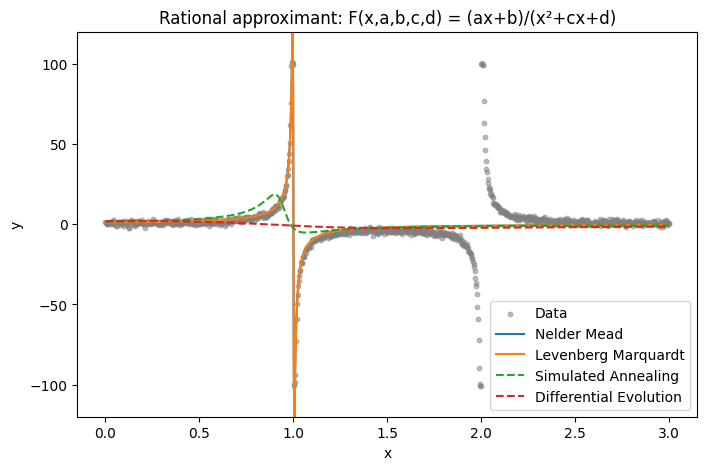

In [363]:
x_plot = xs
plt.figure(figsize=(8, 5))
plt.scatter(xs, ys, s=10, color="gray", alpha=0.5, label="Data")

plt.plot(x_plot, [approximant(x, nm_1, nm_2, nm_3, nm_4) for x in x_plot], label="Nelder Mead")
plt.plot(x_plot, [approximant(x, lm_1, lm_2, lm_3, lm_4) for x in x_plot], label="Levenberg Marquardt")
plt.plot(x_plot, [approximant(x, sa_1, sa_2, sa_3, sa_4) for x in x_plot], label="Simulated Annealing", linestyle="--")
plt.plot(x_plot, [approximant(x, de_1, de_2, de_3, de_4) for x in x_plot], label="Differential Evolution", linestyle="--")

plt.ylim(-120, 120)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Rational approximant: F(x,a,b,c,d) = (ax+b)/(x²+cx+d)")
plt.legend(loc="lower right")
plt.show()

### Conclusion  

The first two methods (Nelder-Mead and Levenberg-Marquardt) converged to virtually the same point, and their resulting function values ​​match accordingly. The other two methods (Simulated Annealing and Differential Evolution) performed worse; they yielded higher D-values ​​that differed from one another. These methods do not guarantee convergence; they run for a fixed number of steps and produce different results each time.
In terms of iterations and computations, Levenberg-Marquardt proved to be the most efficient, while Simulated Annealing required the highest number of iterations.


## Task 2

Choose at least 15 cities in the world having land transport connections between
them. Calculate the distance matrix for them and then apply the Simulated Annealing
method to solve the corresponding Travelling Salesman Problem. Visualize the
results at the first and the last iteration. If necessary, use the city dataset from https://people.sc.fsu.edu/~jburkardt/datasets/cities/cities.html



In [364]:
dist ="""0  29  82  46  68  52  72  42  51  55  29  74  23  72  46
   29   0  55  46  42  43  43  23  23  31  41  51  11  52  21
   82  55   0  68  46  55  23  43  41  29  79  21  64  31  51
   46  46  68   0  82  15  72  31  62  42  21  51  51  43  64
   68  42  46  82   0  74  23  52  21  46  82  58  46  65  23
   52  43  55  15  74   0  61  23  55  31  33  37  51  29  59
   72  43  23  72  23  61   0  42  23  31  77  37  51  46  33
   42  23  43  31  52  23  42  0  33   15  37  33  33  31  37
   51  23  41  62  21  55  23  33   0  29  62  46  29  51  11
   55  31  29  42  46  31  31  15  29   0  51  21  41  23  37
   29  41  79  21  82  33  77  37  62  51   0  65  42  59  61
   74  51  21  51  58  37  37  33  46  21  65   0  61  11  55
   23  11  64  51  46  51  51  33  29  41  42  61   0  62  23
   72  52  31  43  65  29  46  31  51  23  59  11  62   0  59
   46  21  51  64  23  59  33  37  11  37  61  55  23  59   0"""

dist_list = []
for i in dist.strip().split('\n'):
  dist_list.append([int(s) for s in i.split()])

dist_list


[[0, 29, 82, 46, 68, 52, 72, 42, 51, 55, 29, 74, 23, 72, 46],
 [29, 0, 55, 46, 42, 43, 43, 23, 23, 31, 41, 51, 11, 52, 21],
 [82, 55, 0, 68, 46, 55, 23, 43, 41, 29, 79, 21, 64, 31, 51],
 [46, 46, 68, 0, 82, 15, 72, 31, 62, 42, 21, 51, 51, 43, 64],
 [68, 42, 46, 82, 0, 74, 23, 52, 21, 46, 82, 58, 46, 65, 23],
 [52, 43, 55, 15, 74, 0, 61, 23, 55, 31, 33, 37, 51, 29, 59],
 [72, 43, 23, 72, 23, 61, 0, 42, 23, 31, 77, 37, 51, 46, 33],
 [42, 23, 43, 31, 52, 23, 42, 0, 33, 15, 37, 33, 33, 31, 37],
 [51, 23, 41, 62, 21, 55, 23, 33, 0, 29, 62, 46, 29, 51, 11],
 [55, 31, 29, 42, 46, 31, 31, 15, 29, 0, 51, 21, 41, 23, 37],
 [29, 41, 79, 21, 82, 33, 77, 37, 62, 51, 0, 65, 42, 59, 61],
 [74, 51, 21, 51, 58, 37, 37, 33, 46, 21, 65, 0, 61, 11, 55],
 [23, 11, 64, 51, 46, 51, 51, 33, 29, 41, 42, 61, 0, 62, 23],
 [72, 52, 31, 43, 65, 29, 46, 31, 51, 23, 59, 11, 62, 0, 59],
 [46, 21, 51, 64, 23, 59, 33, 37, 11, 37, 61, 55, 23, 59, 0]]

In [365]:
coordinates = """  0.549963E-07  0.985808E-08
  -28.8733     -0.797739E-07
  -79.2916      -21.4033
  -14.6577      -43.3896
  -64.7473       21.8982
  -29.0585      -43.2167
  -72.0785      0.181581
  -36.0366      -21.6135
  -50.4808       7.37447
  -50.5859      -21.5882
 -0.135819      -28.7293
  -65.0866      -36.0625
  -21.4983       7.31942
  -57.5687      -43.2506
  -43.0700       14.5548   """

coordinates_list = []
for i in coordinates.strip().split('\n'):
  coordinates_list.append([float(s) for s in i.split()])

coordinates_list

[[5.49963e-08, 9.85808e-09],
 [-28.8733, -7.97739e-08],
 [-79.2916, -21.4033],
 [-14.6577, -43.3896],
 [-64.7473, 21.8982],
 [-29.0585, -43.2167],
 [-72.0785, 0.181581],
 [-36.0366, -21.6135],
 [-50.4808, 7.37447],
 [-50.5859, -21.5882],
 [-0.135819, -28.7293],
 [-65.0866, -36.0625],
 [-21.4983, 7.31942],
 [-57.5687, -43.2506],
 [-43.07, 14.5548]]

In [366]:
def route_len(route, dist):
  length = 0
  for i in range(len(route)):
    length += dist[route[i]][route[(i+1) % len(route)]]
  return length

In [367]:
def new_route(route):
  new_route = route.copy()
  random_city1, random_city2 = random.sample(range(len(new_route)), 2)
  new_route[random_city1], new_route[random_city2] = new_route[random_city2], new_route[random_city1]
  return new_route


In [368]:
def SA_salesman_problem(dist_list, T0, max_iter, alpha):
  calcs_cnt = 0
  current_route = random.sample(range(15), 15)
  first_route = current_route.copy()
  first_route_len = route_len(first_route, dist_list)
  calcs_cnt += 1
  iterations = 0
  dist_cur = route_len(current_route, dist_list)
  calcs_cnt += 1
  best, dist_best = current_route, dist_cur
  T = T0

  for i in range(max_iter):
    candidate = new_route(current_route)
    dist_cand = route_len(candidate, dist_list)
    calcs_cnt += 1
    if dist_cur > dist_cand:
      dist_cur = dist_cand
      current_route = candidate

    else:
      p = math.exp(-(dist_cand - dist_cur) / T)
      if random.uniform(0, 1) < p:
        dist_cur = dist_cand
        current_route = candidate
    if dist_cur < dist_best:
      dist_best = dist_cur
      best = current_route
    T *= alpha
    iterations += 1

  return first_route, first_route_len, best, dist_best, calcs_cnt, max_iter

In [369]:
first_route, first_route_len, best, dist_best, calcs_cnt, max_iter = SA_salesman_problem(dist_list, 100, 5000,  0.999)
first_route, first_route_len, best, dist_best, calcs_cnt, max_iter

([8, 13, 0, 14, 2, 1, 9, 6, 10, 11, 3, 12, 4, 5, 7],
 757,
 [0, 10, 3, 5, 13, 11, 2, 6, 4, 14, 8, 9, 7, 1, 12],
 307,
 5002,
 5000)

In [370]:
def plots(route, coordinates_list):
  x_coords = []
  for i in route:
    x_coords.append(coordinates_list[i][0])

  y_coords = []
  for i in route:
    y_coords.append(coordinates_list[i][1])

  dx = []
  dy = []
  n = len(route)
  for k in range(n):
    dx.append(x_coords[(k + 1) % n] - x_coords[k])
    dy.append(y_coords[(k + 1) % n] - y_coords[k])

  plt.scatter(x_coords, y_coords)
  plt.quiver(x_coords, y_coords, dx, dy, scale = 1, color = 'midnightblue', width = 0.0045, scale_units = 'xy', angles = 'xy')

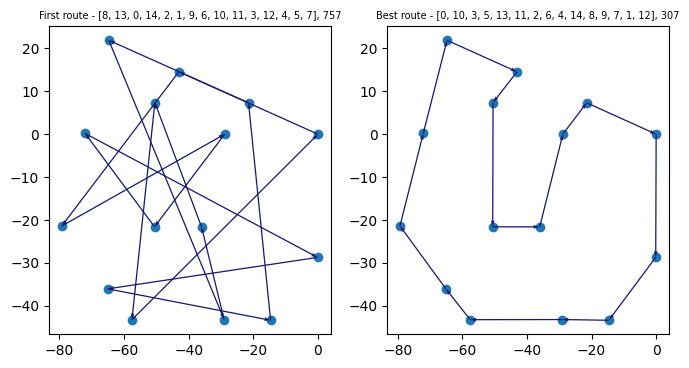

In [371]:
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plots(first_route, coordinates_list)
plt.title(f"First route - {first_route}, {first_route_len}", fontsize = 7)

plt.subplot(1, 2, 2)
plots(best, coordinates_list)
plt.title(f"Best route - {best}, {dist_best}", fontsize = 7)
plt.show()

### Conclusion  

Data from https://people.sc.fsu.edu/~jburkardt/datasets/cities/cities.html was used  


Using a selected random seed and tuned parameters, the Simulated Annealing method reduces the route length from 757 to 307 over 5,000 iterations. The source lists the shortest route for this dataset as having a length of 291, meaning the implemented method came close to the optimum. However, the method is highly sensitive to parameters; reducing the number of iterations while increasing the temperature resulted in significantly poorer performance (by a margin of around 200).